In [7]:
# import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

Data Cleaning

In [8]:
# load the dataset
data = pd.read_csv( r"C:\Users\SART\OneDrive\Documents\DataSets\Chronic_Kidney_disease_dataset1.csv")
# Show the first 5 rows as a dataframe
data.head(12)
# data.info()  #data type and null values

,age,gender,blood_pressure,specific_gravity,albumin,sugar,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,anemia,pedal_edema,ckd
0,62.0,female,50.0,1.020,4,4,normal,absent,absent,98.1,...,38.3,10132.0,5.8,yes,yes,yes,good,yes,no,1
1,44.0,female,90.4,1.010,1,0,normal,absent,absent,186.2,...,41.0,6703.0,6.0,yes,yes,no,good,yes,no,0
2,20.0,male,65.1,1.010,0,0,normal,absent,absent,201.3,...,36.5,6712.0,5.6,yes,no,no,good,no,no,0
3,66.0,female,99.1,1.025,2,0,normal,absent,absent,151.9,...,38.1,5327.0,5.7,no,yes,yes,good,yes,no,0
4,54.0,male,70.2,1.020,1,0,normal,absent,absent,163.7,...,31.4,6573.0,3.9,yes,yes,no,good,yes,no,0
5,34.0,male,102.0,1.020,0,0,normal,absent,absent,144.1,...,38.2,8997.0,4.0,no,no,no,good,no,no,0
6,44.0,male,66.1,1.025,2,0,normal,absent,absent,174.1,...,42.8,9871.0,6.0,yes,no,no,good,no,no,0
7,36.0,male,93.7,1.015,2,0,normal,absent,absent,264.3,...,40.8,6975.0,6.2,yes,no,no,poor,yes,no,0
8,58.0,male,95.7,1.025,2,0,abnormal,absent,absent,160.2,...,30.6,8273.0,4.6,no,no,no,poor,yes,no,0
9,34.0,male,98.8,1.015,1,0,abnormal,absent,absent,156.1,...,39.0,6582.0,4.3,no,no,no,good,no,no,0


 EDA (Exploratory Data Analysis)

In [9]:
data.shape  
data.columns  #column names
data.info()  #data type and null values
data.describe()  #numerical value stats
data.isnull().sum()  #counting missing values
# data.head(10)  
# data.tail(10)

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      30000 non-null  float64
 1   gender                   30000 non-null  str    
 2   blood_pressure           30000 non-null  float64
 3   specific_gravity         30000 non-null  float64
 4   albumin                  30000 non-null  int64  
 5   sugar                    30000 non-null  int64  
 6   pus_cell                 30000 non-null  str    
 7   pus_cell_clumps          30000 non-null  str    
 8   bacteria                 30000 non-null  str    
 9   blood_glucose_random     30000 non-null  float64
 10  blood_urea               30000 non-null  float64
 11  serum_creatinine         30000 non-null  float64
 12  sodium                   30000 non-null  float64
 13  potassium                30000 non-null  float64
 14  hemoglobin               30000 no

age                        0
gender                     0
blood_pressure             0
specific_gravity           0
albumin                    0
sugar                      0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
blood_glucose_random       0
blood_urea                 0
serum_creatinine           0
sodium                     0
potassium                  0
hemoglobin                 0
packed_cell_volume         0
white_blood_cell_count     0
red_blood_cell_count       0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
anemia                     0
pedal_edema                0
ckd                        0
dtype: int64

Feature Engineering

  Counting of CKD vs Non-CKD patients

In [10]:
# Count how many CKD (1) and Non-CKD (0) in dataset
data['ckd'].value_counts()

ckd
0    25032
1     4968
Name: count, dtype: int64

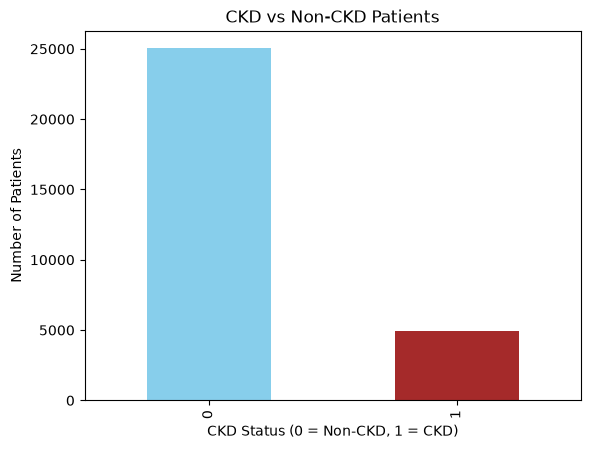

In [11]:
import matplotlib.pyplot as plt  

data['ckd'].value_counts().plot(kind='bar', color=['skyblue', 'brown'])
plt.xlabel("CKD Status (0 = Non-CKD, 1 = CKD)")
plt.ylabel("Number of Patients")
plt.title("CKD vs Non-CKD Patients")
plt.show()

In [12]:
# # Simple bar plot for CKD status (0 = Non-CKD, 1 = CKD)
# data['ckd'].value_counts().plot(kind='bar', color=['skyblue', 'red'])
# plt.show()

<Axes: >

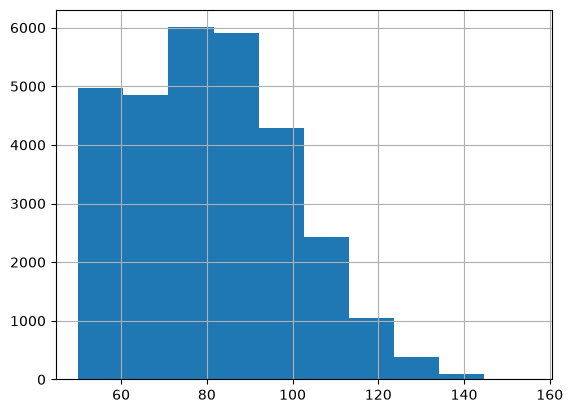

In [13]:
# Histogram of blood pressure
data['blood_pressure'].hist()

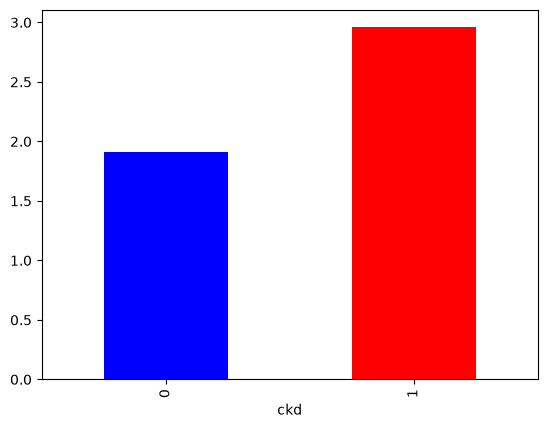

In [14]:
# Average serum creatinine for CKD vs Non-CKD
data.groupby('ckd')['serum_creatinine'].mean().plot(kind='bar',color=['blue', 'red'])
plt.show()

 Encoding categorical variables

In [15]:
# convert yes/no or normal/abnormal to 1/0
binary_columns = ['hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 
               'appetite', 'anemia', 'pedal_edema', 'pus_cell', 'pus_cell_clumps', 'bacteria']

for col in binary_columns:
    data[col] = data[col].map({'yes':1, 'no':0, 'good':1, 'poor':0, 'normal':0, 'abnormal':1, 'absent':0, 'present':1})

# Convert gender: male=1, female=0
data['gender'] = data['gender'].map({'male':1, 'female':0})

In [16]:
# data.tail(10) # 

In [17]:
# data['ckd'].value_counts()

 Checking the EDA after encoding

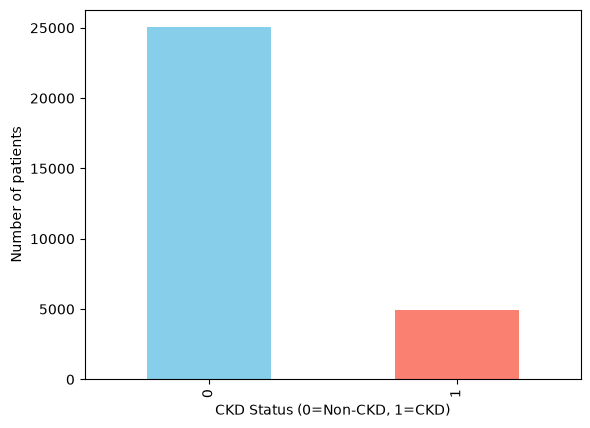

In [18]:
# Check CKD distribution
data['ckd'].value_counts()

# Plot simple bar chart
import matplotlib.pyplot as plt

data['ckd'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.xlabel("CKD Status (0=Non-CKD, 1=CKD)")
plt.ylabel("Number of patients")
plt.show()

Train Multiple Models

Split data into features and target(train test split)

In [19]:
# Features and target
X = data.drop('ckd', axis=1)
y = data['ckd']

# Split 80% train, 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #0.2 ..>20%


 Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8836666666666667
Confusion Matrix:
 [[4814  160]
 [ 538  488]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93      4974
           1       0.75      0.48      0.58      1026

    accuracy                           0.88      6000
   macro avg       0.83      0.72      0.76      6000
weighted avg       0.87      0.88      0.87      6000



d:\ML,AI & DS PROJECTS\ml_work\ml_flow\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision tree & Random forest

In [21]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.9378333333333333
Random Forest Accuracy: 0.9738333333333333


[[4833  141]
 [ 979   47]]


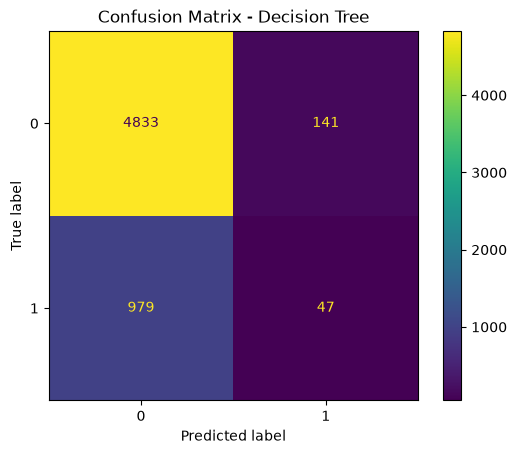

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
# Confusion Matrix
print(confusion_matrix(y_test, 
                y_pred))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=dt.classes_)
plt.plot(cmap=plt.cm.Reds)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

K-NN (K-Nearest Neighbors)

In [23]:
# k-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8133333333333334


Hyperparameter Tuning 

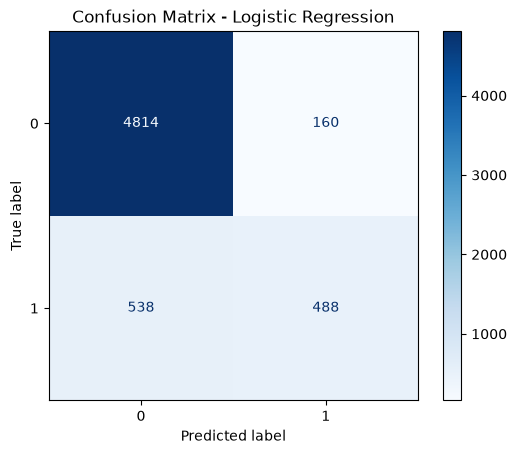

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
# Confusion Matrix
cm = confusion_matrix(y_test, 
                y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Scale the data using StandardScaler but random forest and decision tree do not require feature scaling. So, we will only scale the data .

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
data.head()

,age,gender,blood_pressure,specific_gravity,albumin,sugar,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,anemia,pedal_edema,ckd
0,62.0,0,50.0,1.020,4,4,0,0,0,98.1,...,38.3,10132.0,5.8,1,1,1,1,1,0,1
1,44.0,0,90.4,1.010,1,0,0,0,0,186.2,...,41.0,6703.0,6.0,1,1,0,1,1,0,0
2,20.0,1,65.1,1.010,0,0,0,0,0,201.3,...,36.5,6712.0,5.6,1,0,0,1,0,0,0
3,66.0,0,99.1,1.025,2,0,0,0,0,151.9,...,38.1,5327.0,5.7,0,1,1,1,1,0,0
4,54.0,1,70.2,1.020,1,0,0,0,0,163.7,...,31.4,6573.0,3.9,1,1,0,1,1,0,0


In [27]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced')

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.975


Cross validation & ROC_AUC_SCore

In [28]:
#Cross-validation
from sklearn.model_selection import cross_val_score
score = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross-validation scores:", score)
print("Average CV score:", score.mean())


Cross-validation scores: [0.96604167 0.97083333 0.969375   0.96395833 0.971875  ]
Average CV score: 0.9684166666666666


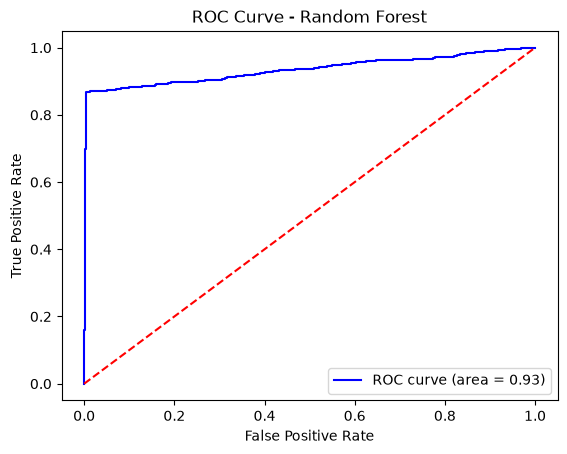

In [29]:
#ROC Curve
from sklearn.metrics import roc_curve, auc
y_prob_rf = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 (CKD)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()


[[4958   16]
 [ 134  892]]


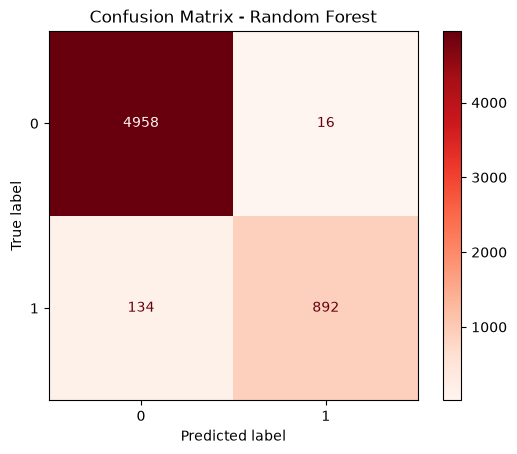

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(confusion_matrix(y_test, 
                y_pred_rf))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,cmap=plt.cm.Reds)
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [31]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
# 'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

# grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
# grid_search.fit(X_train, y_train)
# print("Best Params:", grid_search.best_params_)
# print("Best Score:", grid_search.best_score_)

 Now Comparing all models Accuracy ,Recall ,F1 Score side by side

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Put your models in a dictionary
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}

# Prepare a list to store results
results = []

# Loop through each model
for name, model in models.items():
    y_pred = model.predict(X_test)  # predict on test set
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Show the comparison table
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.883667   0.753086  0.475634  0.583035
1        Decision Tree  0.937833   0.810066  0.831384  0.820587
2        Random Forest  0.975000   0.982379  0.869396  0.922441
3                  KNN  0.813333   0.250000  0.045809  0.077430


 Best model

In [33]:
# Find the model with the highest F1-Score
best_model_idx = results_df['F1-Score'].idxmax()
results_df['Best Model'] = ""  # create a new column
results_df.loc[best_model_idx, 'Best Model'] = "<-- Best!"

# Show the comparison table
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score Best Model
0  Logistic Regression  0.883667   0.753086  0.475634  0.583035           
1        Decision Tree  0.937833   0.810066  0.831384  0.820587           
2        Random Forest  0.975000   0.982379  0.869396  0.922441  <-- Best!
3                  KNN  0.813333   0.250000  0.045809  0.077430           


In [34]:
best_model_name = results_df.loc[best_model_idx, 'Model']  # assuming your column with model names is 'Model'
print("The best model is:", best_model_name)

The best model is: Random Forest


saving the best model

In [35]:
import joblib

# Assuming 'models' is a dictionary with model names as keys and trained model objects as values
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model = models[best_model_name]  # get the trained model object

# Save it
joblib.dump(best_model, "best_ml_model.pkl")
print(f"Saved {best_model_name} as best_ml_model.pkl")

Saved Random Forest as best_ml_model.pkl


In [36]:
import numpy as np
import pandas as pd
import sklearn
import streamlit as st

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("Streamlit version:", st.__version__)

NumPy version: 2.5.1
Pandas version: 3.0.5
Scikit-learn version: 1.9.0
Streamlit version: 1.60.0
